<a href="https://colab.research.google.com/github/BandaAkshitha/PRODIGY_DS_03/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [3]:
df=pd.read_csv('/content/bank-full.csv')

View Dataset

In [4]:
df.head()

,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
0,"58;""management"";""married"";""tertiary"";""no"";2143..."
1,"44;""technician"";""single"";""secondary"";""no"";29;""..."
2,"33;""entrepreneur"";""married"";""secondary"";""no"";2..."
3,"47;""blue-collar"";""married"";""unknown"";""no"";1506..."
4,"33;""unknown"";""single"";""unknown"";""no"";1;""no"";""n..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 1 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                --------------  ----- 
 0   age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"  45211 non-null  object
dtypes: object(1)
memory usage: 353.3+ KB


In [6]:
df.shape

(45211, 1)

In [7]:
df.describe()

,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
count,45211
unique,45211
top,"37;""entrepreneur"";""married"";""secondary"";""no"";2..."
freq,1


Check Missing Values

In [8]:
df.isnull().sum()

,0
"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y""",0


Explore Target Variable

In [10]:
df = pd.read_csv('/content/bank-full.csv', sep=';')
df['y'].value_counts()

,count
y,
no,39922
yes,5289


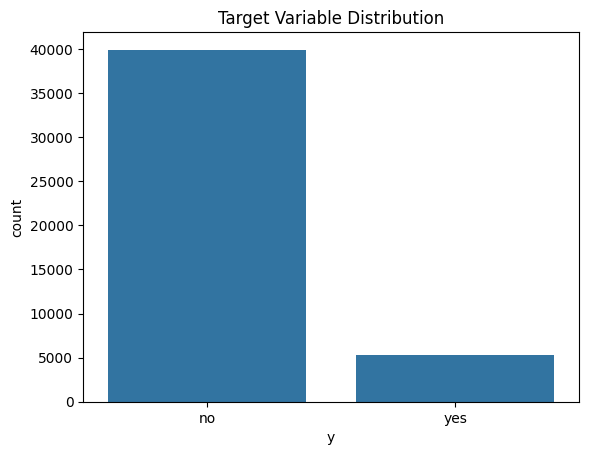

In [11]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

Convert Categorical Columns

In [12]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [13]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


Separate Features and Target

In [14]:
X = df.drop('y', axis=1)
y = df['y']

Split Dataset

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Decision Tree Model

In [16]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

Make Predictions

In [17]:
y_pred = model.predict(X_test)

Calculate Accuracy

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8848833351763795


Classification Report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94      7952
           1       0.55      0.23      0.33      1091

    accuracy                           0.88      9043
   macro avg       0.73      0.60      0.63      9043
weighted avg       0.86      0.88      0.86      9043



Confusion Matrix

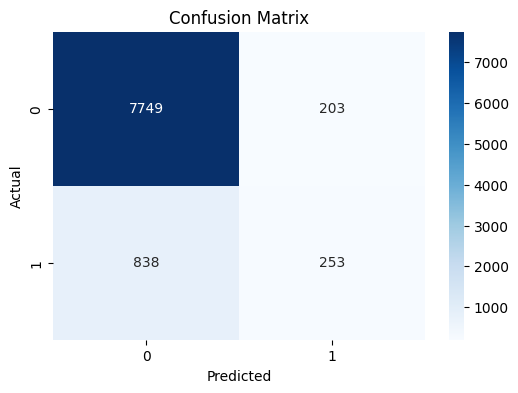

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Visualize Decision Tree

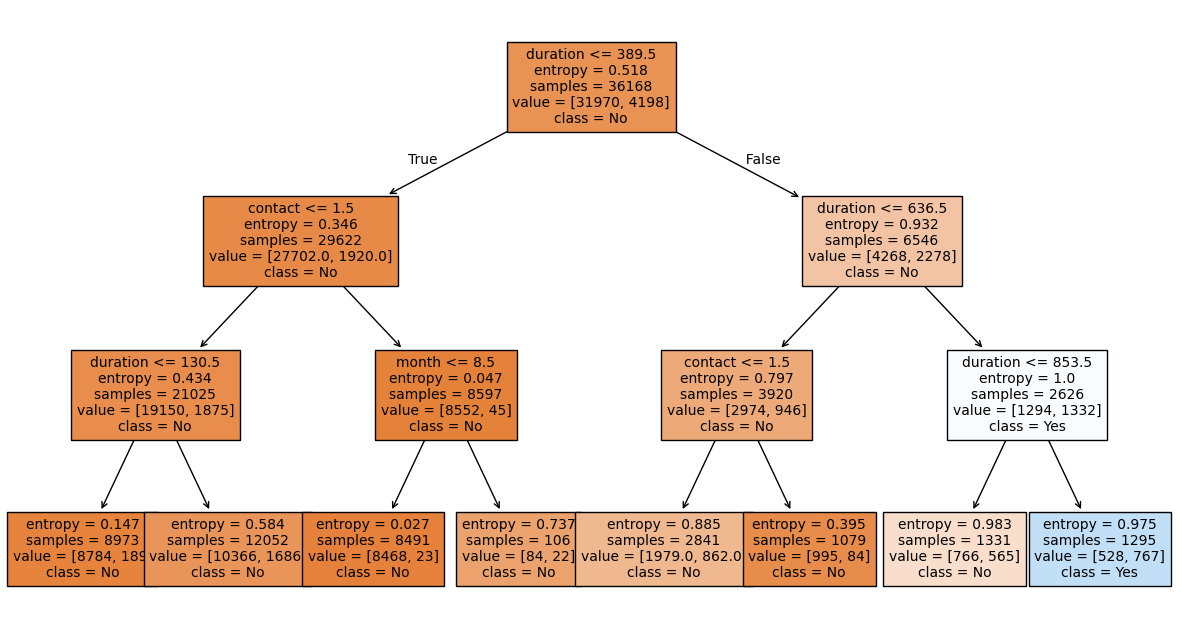

In [22]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True,
    fontsize=10
)

plt.show()

Feature Importance

In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

      Feature  Importance
11   duration    0.777075
8     contact    0.201318
10      month    0.021607
0         age    0.000000
4     default    0.000000
1         job    0.000000
2     marital    0.000000
3   education    0.000000
7        loan    0.000000
6     housing    0.000000


Plot Feature Importance

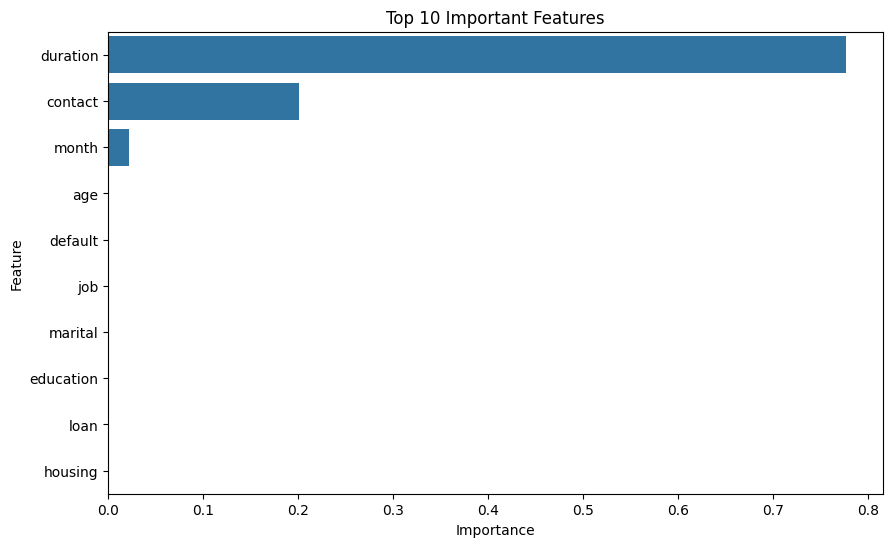

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

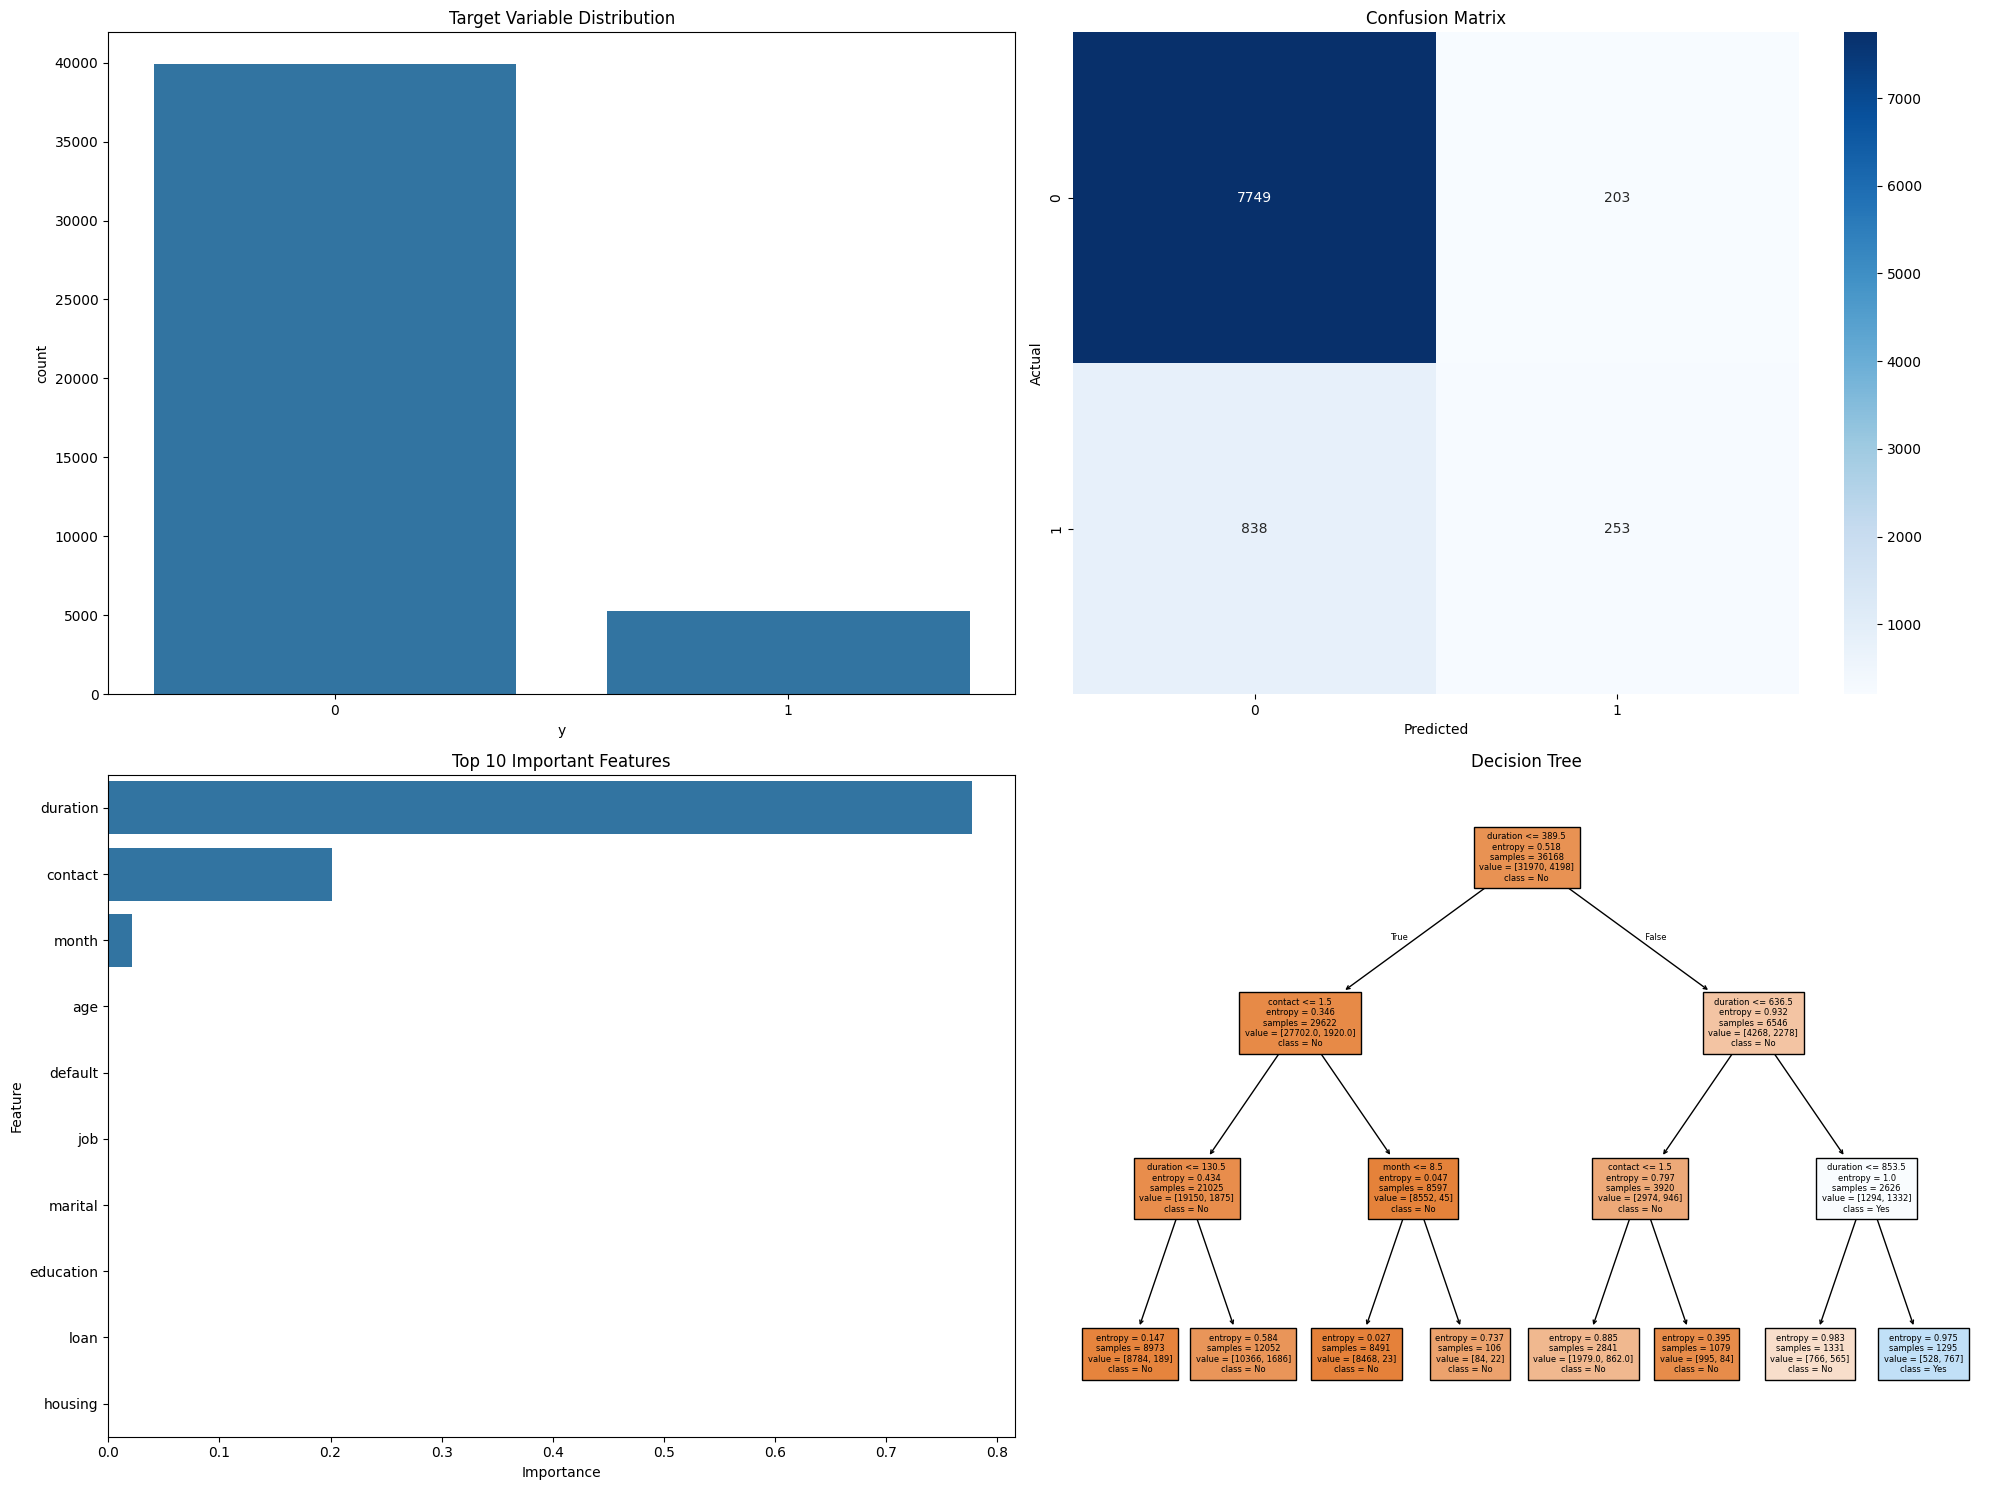

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# 1. Target Variable Distribution
sns.countplot(x='y', data=df, ax=axes[0,0])
axes[0,0].set_title("Target Variable Distribution")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0,1]
)
axes[0,1].set_title("Confusion Matrix")
axes[0,1].set_xlabel("Predicted")
axes[0,1].set_ylabel("Actual")

# 3. Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10),
    ax=axes[1,0]
)
axes[1,0].set_title("Top 10 Important Features")

# 4. Decision Tree
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    fontsize=6,
    ax=axes[1,1]
)
axes[1,1].set_title("Decision Tree")

plt.tight_layout()

# Save High-Quality Image
plt.savefig(
    "Task03_All_Graphs.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
from google.colab import files
files.download("Task03_All_Graphs.png")